# Examining Raman scattering when $b_{b,p}$ is low

In [24]:
# imports
import numpy as np
from matplotlib import pyplot as plt

from ocpy.hydrolight import loisel23
from ocpy.utils import plotting

from bing.fitting import l23 as bing_l23
from bing.rt import rrs
from bing.models import utils as model_utils


In [5]:
WV_REF = 700.
def find_lowest_bbp_idx(rank:int=1,ds=None, wv_ref:float=WV_REF):
    """Locate the L23 spectrum with the smallest bbp at a reference wavelength.

    In the Loisel et al. (2023) Hydrolight dataset the particulate
    backscattering is stored as ``bbnw`` (non-water backscattering).  We
    use that as the proxy for ``bbp`` since the two are equivalent in
    these clear-water simulations.

    Parameters
    ----------
    rank : int
        Rank of the spectrum to select.  Default is 1 (smallest).
    ds : xarray.Dataset, optional
        Pre-loaded L23 dataset.  Loaded if not provided.
    wv_ref : float, optional
        Reference wavelength (nm) at which to evaluate bbp.

    Returns
    -------
    idx : int
        Row index in the L23 dataset with the smallest bbp(wv_ref).
    bbp_value : float
        bbp value at ``wv_ref`` for that spectrum.
    """
    if ds is None:
        ds = loisel23.load_ds(4, 0)

    # Locate the closest wavelength index
    wave = ds.Lambda.data
    iwv = int(np.argmin(np.abs(wave - wv_ref)))

    # Sort the bbnw values at the reference wavelength
    bbnw_ref = ds.bbnw.data[:, iwv]
    sorted_idx = np.argsort(bbnw_ref)
    idx = sorted_idx[rank-1]

    # bbnw across all spectra at the reference wavelength
    return idx, float(bbnw_ref[idx])

# Load up

## L23

In [3]:
ds_elastic = loisel23.load_ds(1, 0)

In [6]:
rank = 1
idx, bbp_value = find_lowest_bbp_idx(rank=rank, ds=ds_elastic)
idx, bbp_value

(np.int64(3003), 7.981000089785084e-05)

## Spectrum

In [11]:
wv_min = 400.  # Keeps the Raman calculation where we have UV coverage of bb, a
odict = bing_l23.load_one_l23(idx, ds=ds_elastic, wv_min=wv_min)

In [17]:
odict['a'].shape, odict['wave'].shape

((71,), (71,))

# Raman

## Prep

In [19]:
models = model_utils.init(['ExpBricaud', 'Pow'],  odict['true_wave'])
a_ex = odict['f_a'](models[0].wave_ex)
bb_ex = odict['f_bb'](models[1].wave_ex)

In [21]:
corr = rrs.calc_raman_correction_factor(odict['a'], odict['bb'], a_ex, bb_ex, models[1].bb_R)

# Plot

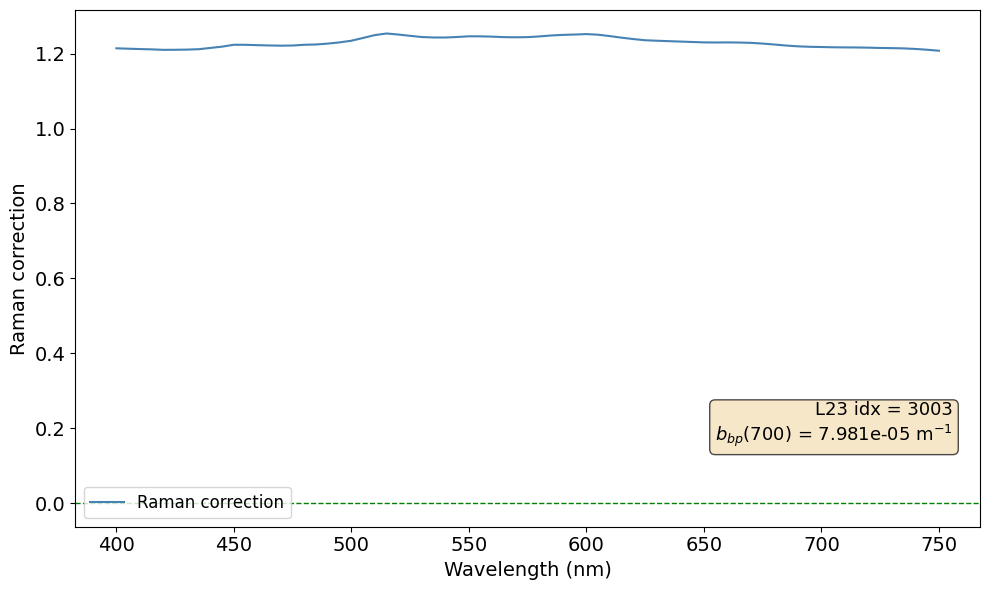

In [28]:
fig = plt.figure(figsize=(10, 6))
ax = plt.gca()

# Reference noise-free curve for context
ax.plot(odict['wave'], corr, color='steelblue',
        ls='-', lw=1.5, label='Raman correction')

ax.set_xlabel('Wavelength (nm)')
ax.set_ylabel('Raman correction')

# Annotate bbp value and L23 index
txt = (f"L23 idx = {idx}\n"
       r"$b_{bp}(" + f"{WV_REF:.0f}" + r")$ = "
       f"{bbp_value:.3e} m$^{{-1}}$")
ax.text(0.97, 0.15, txt, transform=ax.transAxes, fontsize=13,
        ha='right', va='bottom',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.7))

ax.legend(loc='lower left', fontsize=12)
plotting.set_fontsize(ax, 14)

# Zero line
ax.axhline(0., color='g', ls='--', lw=1.)

# Log scale y-axis
#ax.set_yscale('log')

plt.tight_layout()
plt.show()